# 🧬 Pipeline ML Complet — Diagnostic Thyroïdien

**Dataset** : `thyroid0387.csv`  
**Objectif** : Classification du diagnostic thyroïdien (colonne `class`) + modèle multi-output  
**Modèles testés** : Logistic Regression, Random Forest, XGBoost  

---

## 📦 0. Installation & Imports

In [1]:
# Installer les librairies manquantes si nécessaire (Google Colab)
%pip install xgboost imbalanced-learn -q

^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
# ── Imports standards ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn ────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

# ── XGBoost ────────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Imbalanced-learn ───────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Style graphique ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Imports OK')

✅ Imports OK


## 📂 1. Chargement des données

In [2]:
# ── Chargement ─────────────────────────────────────────────────────────────────
# Adapter le chemin selon votre environnement :
# Google Colab : uploader le fichier ou monter Google Drive
# from google.colab import files; files.upload()

FILE_PATH = 'thyroid.csv'   # ← modifier si besoin

df_raw = pd.read_csv(FILE_PATH)
print(f'Dimensions : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes')
df_raw.head()

Dimensions : 9172 lignes × 30 colonnes


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,class
0,29,F,f,f,f,f,f,f,f,t,...,f,?,f,?,f,?,f,?,other,-[840801013]
1,29,F,f,f,f,f,f,f,f,f,...,t,128,f,?,f,?,f,?,other,-[840801014]
2,41,F,f,f,f,f,f,f,f,f,...,f,?,f,?,f,?,t,11,other,-[840801042]
3,36,F,f,f,f,f,f,f,f,f,...,f,?,f,?,f,?,t,26,other,-[840803046]
4,32,F,f,f,f,f,f,f,f,f,...,f,?,f,?,f,?,t,36,other,S[840803047]


In [3]:
# ── Aperçu des types et valeurs manquantes '?' ─────────────────────────────────
missing_q = (df_raw == '?').sum()
print('Colonnes avec des "?" :')
print(missing_q[missing_q > 0])
print()
print('Types :')
print(df_raw.dtypes)

Colonnes avec des "?" :
sex     307
TSH     842
T3     2604
TT4     442
T4U     809
FTI     802
TBG    8823
dtype: int64

Types :
age                          int64
sex                            str
on_thyroxine                   str
query_on_thyroxine             str
on_antithyroid_medication      str
sick                           str
pregnant                       str
thyroid_surgery                str
I131_treatment                 str
query_hypothyroid              str
query_hyperthyroid             str
lithium                        str
goitre                         str
tumor                          str
hypopituitary                  str
psych                          str
TSH_measured                   str
TSH                            str
T3_measured                    str
T3                             str
TT4_measured                   str
TT4                            str
T4U_measured                   str
T4U                            str
FTI_measured                  

## 🧹 2. Nettoyage des données

In [4]:
df = df_raw.copy()

# ── 2.1 Remplacer '?' par NaN ──────────────────────────────────────────────────
df.replace('?', np.nan, inplace=True)
print('NaN après remplacement :')
print(df.isnull().sum()[df.isnull().sum() > 0])

NaN après remplacement :
sex     307
TSH     842
T3     2604
TT4     442
T4U     809
FTI     802
TBG    8823
dtype: int64


Distribution de la variable cible (class) :
class
-      6771
K       436
G       359
I       346
F       233
R       196
A       147
L       115
M       111
N       110
S        85
GK       49
AK       46
J        30
B        21
MK       16
Q        14
O        14
C|I      12
KJ       11
GI       10
H|K       8
D         8
FK        6
C         6
P         5
MI        2
LJ        1
GKJ       1
OI        1
D|R       1
E         1
Name: count, dtype: int64


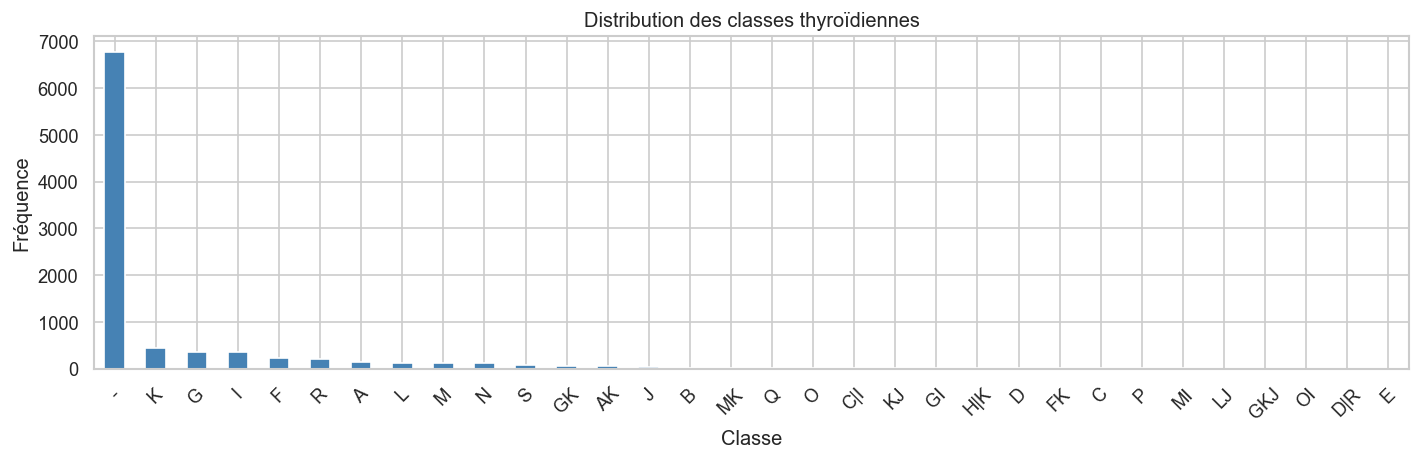

In [5]:
# ── 2.2 Nettoyage de la colonne 'class' ───────────────────────────────────────
# La colonne contient des valeurs comme '-[840801013]', 'K[...]', 'G[...]'
# On extrait uniquement le label avant le '['
import re

def extract_class_label(val):
    """Extrait le code diagnostic (ex: '-', 'K', 'G') de la valeur brute."""
    if pd.isna(val):
        return np.nan
    match = re.match(r'^([^[]+)', str(val))
    return match.group(1).strip() if match else val

df['class'] = df['class'].apply(extract_class_label)

# Distribution des classes
print('Distribution de la variable cible (class) :')
print(df['class'].value_counts())

fig, ax = plt.subplots(figsize=(12, 4))
df['class'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribution des classes thyroïdiennes')
ax.set_xlabel('Classe')
ax.set_ylabel('Fréquence')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# ── 2.3 Création d'une cible binaire : normal ('-') vs pathologique ────────────
# La classe '-' représente l'absence de pathologie thyroïdienne
df['target'] = (df['class'] != '-').astype(int)
print('Cible binaire (0=normal, 1=pathologique) :')
print(df['target'].value_counts())
print(f"Déséquilibre : {df['target'].mean():.1%} de cas pathologiques")

Cible binaire (0=normal, 1=pathologique) :
target
0    6771
1    2401
Name: count, dtype: int64
Déséquilibre : 26.2% de cas pathologiques


In [7]:
# ── 2.4 Suppression des colonnes inutiles ─────────────────────────────────────
# TBG : 96% manquant → on la supprime
# Les colonnes '*_measured' indiquent si la mesure a été faite (redondant avec NaN)
# 'referral_source' : métadonnée administrative peu prédictive
# 'class' : remplacée par 'target'

cols_to_drop = [
    'TBG',            # 96% de NaN
    'TBG_measured',   # redondant
    'TSH_measured',   # redondant (présence mesure ↔ NaN)
    'T3_measured',
    'TT4_measured',
    'T4U_measured',
    'FTI_measured',
    'referral_source',
    'class',
]

df.drop(columns=cols_to_drop, inplace=True)
print(f'Colonnes restantes ({df.shape[1]}) :', df.columns.tolist())

Colonnes restantes (22) : ['age', 'sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'target']


In [8]:
# ── 2.5 Conversion des types ──────────────────────────────────────────────────

# Variables booléennes t/f → 0/1
bool_cols = [
    'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium',
    'goitre', 'tumor', 'hypopituitary', 'psych'
]

for col in bool_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

# Variables numériques
num_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Variable catégorielle : sex (M/F → 0/1)
df['sex'] = df['sex'].map({'M': 1, 'F': 0})

print('Types après conversion :')
print(df.dtypes)
print()
print('NaN restants :')
print(df.isnull().sum()[df.isnull().sum() > 0])

Types après conversion :
age                            int64
sex                          float64
on_thyroxine                   int64
query_on_thyroxine             int64
on_antithyroid_medication      int64
sick                           int64
pregnant                       int64
thyroid_surgery                int64
I131_treatment                 int64
query_hypothyroid              int64
query_hyperthyroid             int64
lithium                        int64
goitre                         int64
tumor                          int64
hypopituitary                  int64
psych                          int64
TSH                          float64
T3                           float64
TT4                          float64
T4U                          float64
FTI                          float64
target                         int64
dtype: object

NaN restants :
sex     307
TSH     842
T3     2604
TT4     442
T4U     809
FTI     802
dtype: int64


## 🔧 3. Feature Engineering

In [9]:
# ── 3.1 Variables dérivées (seuils cliniques) ─────────────────────────────────
# Valeurs normales de référence clinique :
#   TSH  : 0.4 – 4.0 mU/L
#   TT4  : 70  – 180 nmol/L
#   T3   : 1.2 – 3.1 nmol/L
#   FTI  : 70  – 180 (indice)

df['TSH_abnormal']  = ((df['TSH']  < 0.4)  | (df['TSH']  > 4.0)).astype('Int8')
df['TT4_abnormal']  = ((df['TT4']  < 70)   | (df['TT4']  > 180)).astype('Int8')
df['T3_abnormal']   = ((df['T3']   < 1.2)  | (df['T3']   > 3.1)).astype('Int8')
df['FTI_abnormal']  = ((df['FTI']  < 70)   | (df['FTI']  > 180)).astype('Int8')

# Score synthétique d'anomalie hormonale (0 à 4)
df['hormone_score'] = (
    df['TSH_abnormal'].fillna(0).astype(int) +
    df['TT4_abnormal'].fillna(0).astype(int) +
    df['T3_abnormal'].fillna(0).astype(int) +
    df['FTI_abnormal'].fillna(0).astype(int)
)

# Ratio T4U/TT4 (approximation de l'index de thyroxine libre)
df['T4U_TT4_ratio'] = df['T4U'] / (df['TT4'] + 1e-6)

print('Nouvelles features créées :')
print(df[['TSH_abnormal', 'TT4_abnormal', 'T3_abnormal', 'FTI_abnormal',
          'hormone_score', 'T4U_TT4_ratio']].describe())

Nouvelles features créées :
       TSH_abnormal  TT4_abnormal  T3_abnormal  FTI_abnormal  hormone_score  \
count        9172.0        9172.0       9172.0        9172.0    9172.000000   
mean       0.353467      0.125273     0.127453      0.093218       0.699411   
std        0.478072      0.331046     0.333498      0.290754       0.973214   
min             0.0           0.0          0.0           0.0       0.000000   
25%             0.0           0.0          0.0           0.0       0.000000   
50%             0.0           0.0          0.0           0.0       0.000000   
75%             1.0           0.0          0.0           0.0       1.000000   
max             1.0           1.0          1.0           1.0       4.000000   

       T4U_TT4_ratio  
count    8359.000000  
mean        0.011280  
std         0.020078  
min         0.001151  
25%         0.007810  
50%         0.009180  
75%         0.010700  
max         0.620000  


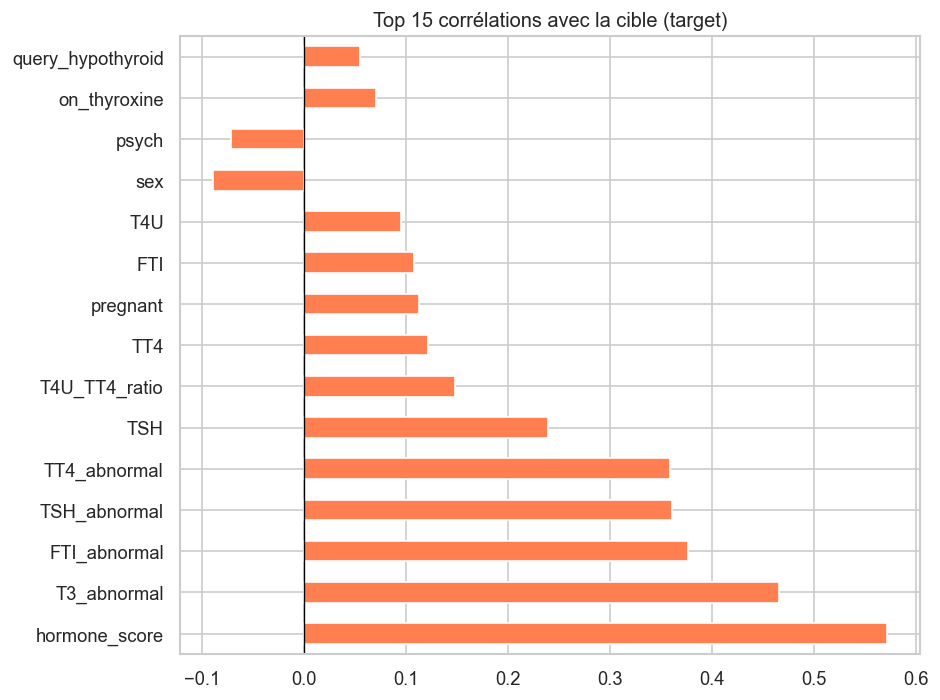

In [10]:
# ── 3.2 Corrélation avec la cible ─────────────────────────────────────────────
corr_with_target = df.select_dtypes(include=[np.number]).corr()['target'].drop('target').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
corr_with_target.head(15).plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 15 corrélations avec la cible (target)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## ⚙️ 4. Préparation du Pipeline ML

In [11]:
# ── 4.1 Définition des features et de la cible ────────────────────────────────

# Exclure les cibles auxiliaires du X principal
TARGET_COL    = 'target'
AUX_TARGETS   = ['TSH_abnormal', 'TT4_abnormal']   # pour le modèle multi-output
EXCLUDE_COLS  = [TARGET_COL] + AUX_TARGETS

X = df.drop(columns=EXCLUDE_COLS)
y = df[TARGET_COL]

# Colonnes numériques et binaires
num_features  = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI',
                 'hormone_score', 'T4U_TT4_ratio']
bin_features  = [c for c in X.columns if c not in num_features]

print(f'Features numériques ({len(num_features)}) :', num_features)
print(f'Features binaires   ({len(bin_features)}) :', bin_features)
print(f'Total features : {X.shape[1]}')

Features numériques (8) : ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'hormone_score', 'T4U_TT4_ratio']
Features binaires   (17) : ['sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'T3_abnormal', 'FTI_abnormal']
Total features : 25


In [12]:
# ── 4.2 Split Train / Test (80/20) ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print(f'Prévalence pathologique — Train: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')

Train : 7337 | Test : 1835
Prévalence pathologique — Train: 26.2% | Test: 26.2%


In [13]:
# ── 4.3 ColumnTransformer ─────────────────────────────────────────────────────
# Numériques : imputation médiane + standardisation
# Binaires   : imputation par la valeur la plus fréquente (mode)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('bin', binary_transformer,  bin_features),
])

print('✅ Preprocessor défini')

✅ Preprocessor défini


In [14]:
# ── 4.4 Gestion du déséquilibre des classes (SMOTE) ───────────────────────────
# Appliquer après preprocessing pour éviter la fuite de données

# Préparation des données pour SMOTE
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

print(f'Avant SMOTE  : {X_train_prep.shape[0]} échantillons | {y_train.sum()} positifs ({y_train.mean():.1%})')
print(f'Après SMOTE  : {X_train_res.shape[0]} échantillons | {y_train_res.sum()} positifs ({y_train_res.mean():.1%})')

Avant SMOTE  : 7337 échantillons | 1921 positifs (26.2%)
Après SMOTE  : 10832 échantillons | 5416 positifs (50.0%)


## 🤖 5. Modélisation & Validation croisée

In [15]:
# ── Fonction d'évaluation réutilisable ────────────────────────────────────────

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    """
    Entraîne le modèle, effectue une validation croisée stratifiée
    et affiche les métriques sur le jeu de test.
    Retourne un dict de résultats.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    cv_results = cross_validate(
        model, X_tr, y_tr, cv=skf,
        scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
        return_train_score=False
    )

    # Entraînement final sur tout le train
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    test_acc  = accuracy_score(y_te, y_pred)
    test_prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    test_rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    test_f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*60}")
    print(f'  {name}')
    print(f"{'='*60}")
    print(f'  CV Accuracy   : {cv_results["test_accuracy"].mean():.4f} ± {cv_results["test_accuracy"].std():.4f}')
    print(f'  CV F1         : {cv_results["test_f1_weighted"].mean():.4f} ± {cv_results["test_f1_weighted"].std():.4f}')
    print(f'  Test Accuracy : {test_acc:.4f}')
    print(f'  Test Precision: {test_prec:.4f}')
    print(f'  Test Recall   : {test_rec:.4f}')
    print(f'  Test F1       : {test_f1:.4f}')
    print()
    print(classification_report(y_te, y_pred, zero_division=0))

    # Matrice de confusion
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, ax=ax, colorbar=False,
                                             display_labels=['Normal', 'Patho'])
    ax.set_title(f'Matrice de confusion — {name}')
    plt.tight_layout()
    plt.show()

    return {
        'model': model, 'name': name,
        'cv_accuracy': cv_results['test_accuracy'].mean(),
        'cv_f1': cv_results['test_f1_weighted'].mean(),
        'test_accuracy': test_acc,
        'test_f1': test_f1,
        'y_pred': y_pred
    }

print('✅ Fonction evaluate_model définie')

✅ Fonction evaluate_model définie



  Logistic Regression
  CV Accuracy   : 0.8655 ± 0.0060
  CV F1         : 0.8653 ± 0.0060
  Test Accuracy : 0.8883
  Test Precision: 0.8941
  Test Recall   : 0.8883
  Test F1       : 0.8902

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      1355
           1       0.76      0.85      0.80       480

    accuracy                           0.89      1835
   macro avg       0.85      0.87      0.86      1835
weighted avg       0.89      0.89      0.89      1835



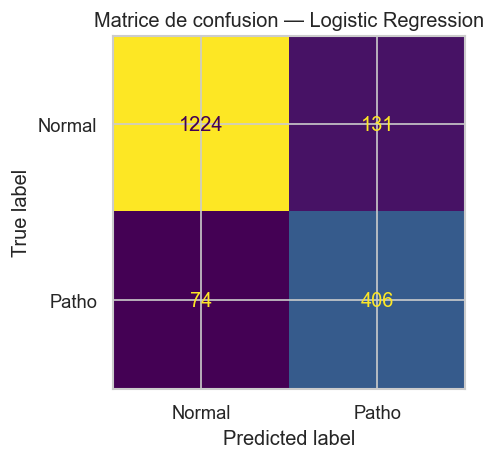

In [16]:
# ── 5.1 Logistic Regression ───────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

res_lr = evaluate_model(
    'Logistic Regression',
    lr,
    X_train_res, y_train_res,
    X_test_prep, y_test
)


  Random Forest
  CV Accuracy   : 0.9566 ± 0.0058
  CV F1         : 0.9566 ± 0.0058
  Test Accuracy : 0.9411
  Test Precision: 0.9440
  Test Recall   : 0.9411
  Test F1       : 0.9419

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1355
           1       0.85      0.93      0.89       480

    accuracy                           0.94      1835
   macro avg       0.92      0.94      0.93      1835
weighted avg       0.94      0.94      0.94      1835



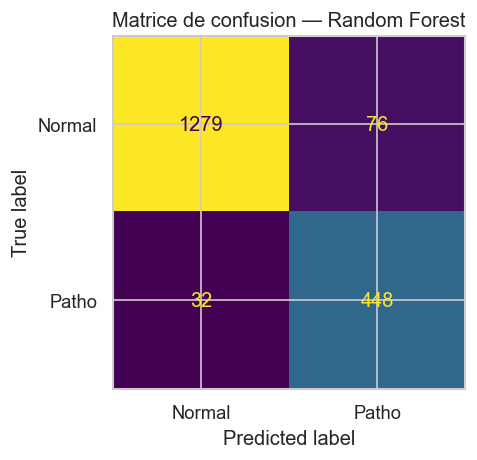

In [17]:
# ── 5.2 Random Forest ─────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)

res_rf = evaluate_model(
    'Random Forest',
    rf,
    X_train_res, y_train_res,
    X_test_prep, y_test
)


  XGBoost
  CV Accuracy   : 0.9555 ± 0.0041
  CV F1         : 0.9555 ± 0.0042
  Test Accuracy : 0.9417
  Test Precision: 0.9438
  Test Recall   : 0.9417
  Test F1       : 0.9423

              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1355
           1       0.86      0.93      0.89       480

    accuracy                           0.94      1835
   macro avg       0.92      0.94      0.93      1835
weighted avg       0.94      0.94      0.94      1835



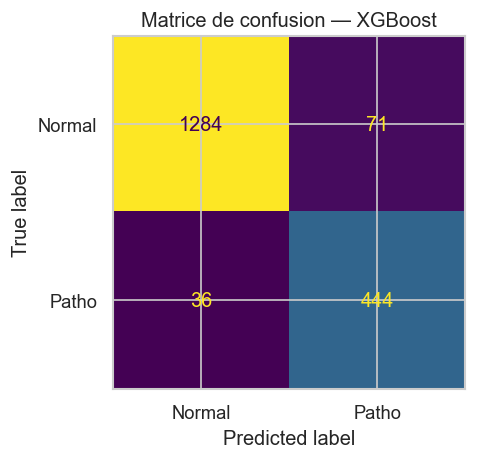

In [18]:
# ── 5.3 XGBoost ───────────────────────────────────────────────────────────────
# scale_pos_weight compense le déséquilibre AVANT SMOTE (si besoin)
xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

res_xgb = evaluate_model(
    'XGBoost',
    xgb,
    X_train_res, y_train_res,
    X_test_prep, y_test
)

## 🔍 6. Optimisation — RandomizedSearchCV

In [19]:
# ── Optimisation du meilleur modèle (Random Forest ou XGBoost) ────────────────
# Adapter l'espace de recherche selon le modèle choisi

print('Optimisation du Random Forest par RandomizedSearchCV...')

param_dist_rf = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 5, 10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2', 0.5],
    'class_weight'      : ['balanced', 'balanced_subsample']
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=30,                # nombre de combinaisons testées
    scoring='f1_weighted',
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rs_rf.fit(X_train_res, y_train_res)

print('\n✅ Meilleurs hyperparamètres RF :')
print(rs_rf.best_params_)
print(f'   F1 CV (best) : {rs_rf.best_score_:.4f}')

Optimisation du Random Forest par RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Meilleurs hyperparamètres RF :
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'class_weight': 'balanced_subsample'}
   F1 CV (best) : 0.9584


In [20]:
# ── Évaluation du modèle optimisé ─────────────────────────────────────────────
best_rf = rs_rf.best_estimator_
y_pred_opt = best_rf.predict(X_test_prep)

print(f'RF Optimisé — Test F1 : {f1_score(y_test, y_pred_opt, average="weighted"):.4f}')
print(f'RF Optimisé — Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}')
print()
print(classification_report(y_test, y_pred_opt, zero_division=0))

RF Optimisé — Test F1 : 0.9435
RF Optimisé — Accuracy: 0.9428

              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1355
           1       0.86      0.93      0.89       480

    accuracy                           0.94      1835
   macro avg       0.92      0.94      0.93      1835
weighted avg       0.95      0.94      0.94      1835



## 📊 7. Comparaison des modèles

             Modèle  CV Accuracy    CV F1  Test Accuracy  Test F1
        RF Optimisé     0.958443 0.958443       0.942779 0.943478
            XGBoost     0.955503 0.955496       0.941689 0.942333
      Random Forest     0.956611 0.956597       0.941144 0.941948
Logistic Regression     0.865491 0.865270       0.888283 0.890214


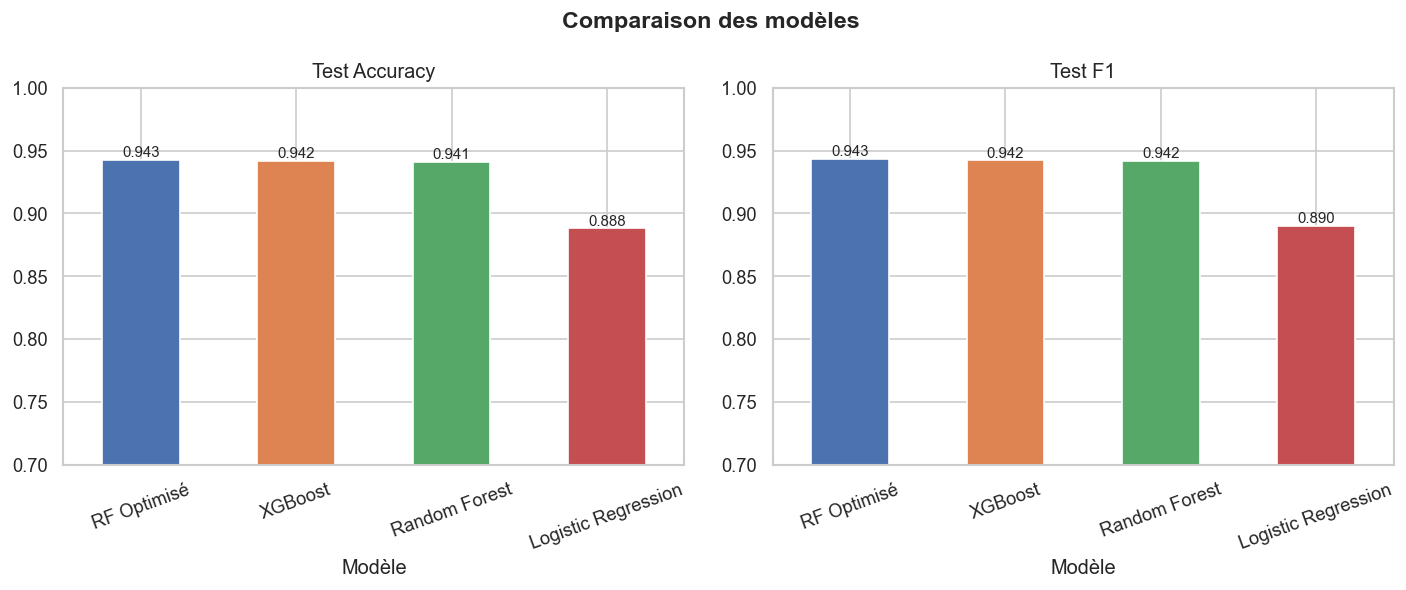

In [21]:
# ── Tableau comparatif ────────────────────────────────────────────────────────
results = pd.DataFrame([
    {'Modèle': res_lr['name'],  'CV Accuracy': res_lr['cv_accuracy'],  'CV F1': res_lr['cv_f1'],  'Test Accuracy': res_lr['test_accuracy'],  'Test F1': res_lr['test_f1']},
    {'Modèle': res_rf['name'],  'CV Accuracy': res_rf['cv_accuracy'],  'CV F1': res_rf['cv_f1'],  'Test Accuracy': res_rf['test_accuracy'],  'Test F1': res_rf['test_f1']},
    {'Modèle': res_xgb['name'], 'CV Accuracy': res_xgb['cv_accuracy'], 'CV F1': res_xgb['cv_f1'], 'Test Accuracy': res_xgb['test_accuracy'], 'Test F1': res_xgb['test_f1']},
    {'Modèle': 'RF Optimisé',
     'CV Accuracy': rs_rf.best_score_,
     'CV F1': rs_rf.best_score_,
     'Test Accuracy': accuracy_score(y_test, y_pred_opt),
     'Test F1': f1_score(y_test, y_pred_opt, average='weighted')}
])

results = results.sort_values('Test F1', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric in zip(axes, ['Test Accuracy', 'Test F1']):
    results.plot.bar(x='Modèle', y=metric, ax=ax, legend=False,
                     color=['#4C72B0','#DD8452','#55A868','#C44E52'])
    ax.set_title(metric)
    ax.set_ylim(0.7, 1.0)
    ax.set_xticklabels(results['Modèle'], rotation=20)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.suptitle('Comparaison des modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🏆 8. Meilleur modèle — Importance des variables

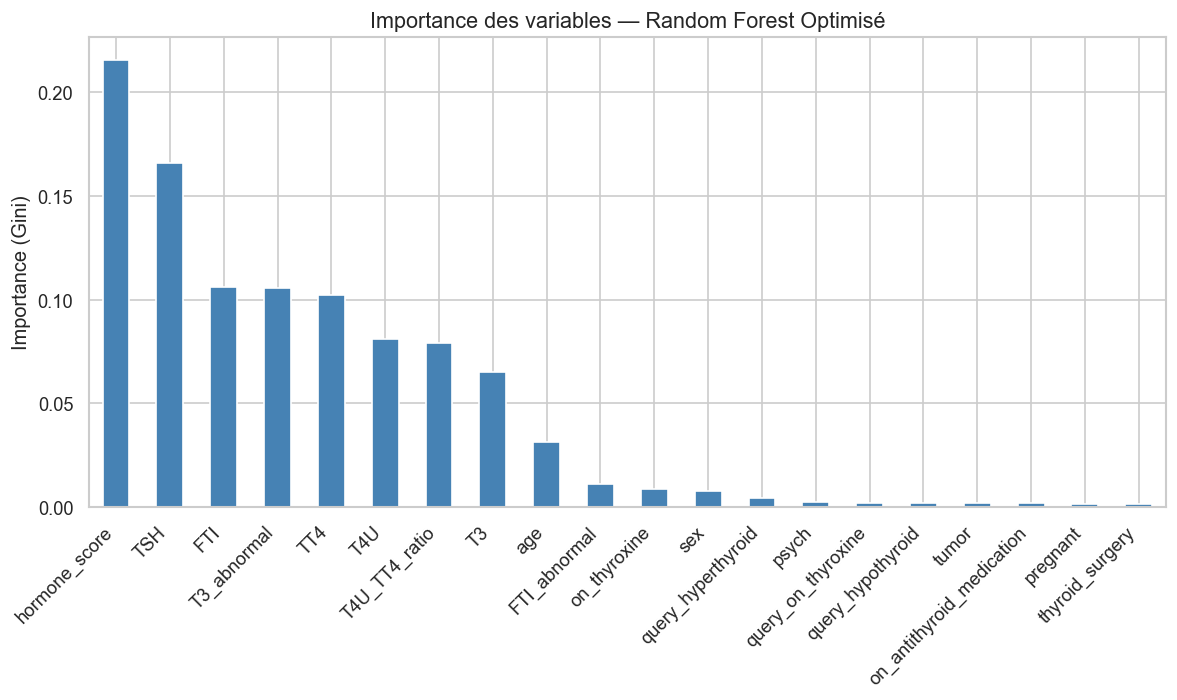


Top 10 variables les plus importantes :
hormone_score    0.215839
TSH              0.166104
FTI              0.105912
T3_abnormal      0.105473
TT4              0.102208
T4U              0.081026
T4U_TT4_ratio    0.079301
T3               0.065264
age              0.031158
FTI_abnormal     0.011154


In [22]:
# ── Importance des features (Random Forest optimisé) ──────────────────────────
feature_names = num_features + bin_features

importances = pd.Series(
    best_rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.head(20).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Importance des variables — Random Forest Optimisé', fontsize=13)
ax.set_ylabel('Importance (Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 10 variables les plus importantes :')
print(importances.head(10).to_string())

## 🎁 9.— Modèle Multi-Output

> **3 cibles simultanées** : `target` (pathologique), `TSH_abnormal`, `TT4_abnormal`

In [23]:
print('Préparation du dataset multi-output (clean)...')

# ── 1. Cibles ──────────────────────────────────────────────
y_multi = df[['target', 'TSH_abnormal', 'TT4_abnormal']].copy()
y_multi['TSH_abnormal'] = y_multi['TSH_abnormal'].fillna(0).astype(int)
y_multi['TT4_abnormal'] = y_multi['TT4_abnormal'].fillna(0).astype(int)

# ── 2. Supprimer les colonnes qui causent DATA LEAKAGE ─────
cols_to_remove = [
    'target', 'TSH_abnormal', 'TT4_abnormal',
    'TSH', 'TT4', 'FTI', 'T3', 'T4U'   
]

X_mo = df.drop(columns=cols_to_remove, errors='ignore')

print('\nColonnes utilisées pour le modèle:')
print(X_mo.columns.tolist())

# ── 3. Split ──────────────────────────────────────────────
X_mo_train, X_mo_test, y_mo_train, y_mo_test = train_test_split(
    X_mo, y_multi, test_size=0.2, random_state=42, stratify=y_multi['target']
)

# ── 4. Détection automatique des types ─────────────────────
num_features = X_mo.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = [c for c in X_mo.columns if c not in num_features]

print(f'\nNum features: {len(num_features)} | Cat features: {len(cat_features)}')

# ── 5. Preprocessing ───────────────────────────────────────
preprocessor_mo = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc', StandardScaler())
    ]), num_features),

    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent'))
    ]), cat_features)
])

X_mo_train_prep = preprocessor_mo.fit_transform(X_mo_train)
X_mo_test_prep  = preprocessor_mo.transform(X_mo_test)

print(f'\nTrain: {X_mo_train_prep.shape} | Test: {X_mo_test_prep.shape}')

# ── 6. Vérification distribution ───────────────────────────
print('\nDistribution des cibles (train) :')
print(y_mo_train.mean().round(3))

Préparation du dataset multi-output (clean)...

Colonnes utilisées pour le modèle:
['age', 'sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'T3_abnormal', 'FTI_abnormal', 'hormone_score', 'T4U_TT4_ratio']

Num features: 18 | Cat features: 2

Train: (7337, 20) | Test: (1835, 20)

Distribution des cibles (train) :
target          0.262
TSH_abnormal    0.353
TT4_abnormal    0.127
dtype: float64


In [24]:
# ── 9.2 Entraînement MultiOutputClassifier ────────────────────────────────────
mo_model = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    n_jobs=-1
)

mo_model.fit(X_mo_train_prep, y_mo_train)
y_mo_pred = mo_model.predict(X_mo_test_prep)
y_mo_pred_df = pd.DataFrame(y_mo_pred, columns=['target', 'TSH_abnormal', 'TT4_abnormal'])

print('\n📊 Résultats du modèle multi-output :\n')
for i, col in enumerate(['target', 'TSH_abnormal', 'TT4_abnormal']):
    f1  = f1_score(y_mo_test[col], y_mo_pred_df[col], average='weighted', zero_division=0)
    acc = accuracy_score(y_mo_test[col], y_mo_pred_df[col])
    print(f'  [{col}]  Accuracy: {acc:.4f}  |  F1: {f1:.4f}')


📊 Résultats du modèle multi-output :

  [target]  Accuracy: 0.8474  |  F1: 0.8432
  [TSH_abnormal]  Accuracy: 0.9646  |  F1: 0.9648
  [TT4_abnormal]  Accuracy: 0.9651  |  F1: 0.9641


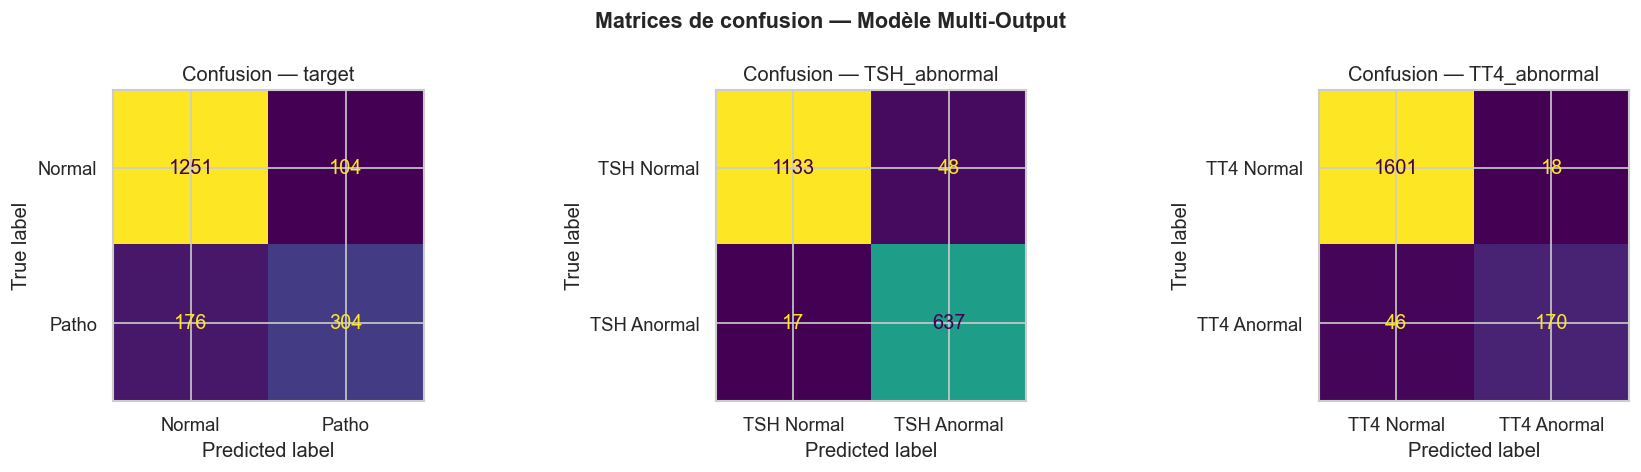

In [25]:
# ── 9.3 Matrices de confusion multi-output ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels_map = {
    'target'       : ['Normal', 'Patho'],
    'TSH_abnormal' : ['TSH Normal', 'TSH Anormal'],
    'TT4_abnormal' : ['TT4 Normal', 'TT4 Anormal']
}

for ax, col in zip(axes, ['target', 'TSH_abnormal', 'TT4_abnormal']):
    ConfusionMatrixDisplay.from_predictions(
        y_mo_test[col], y_mo_pred_df[col],
        ax=ax, colorbar=False,
        display_labels=labels_map[col]
    )
    ax.set_title(f'Confusion — {col}')

plt.suptitle('Matrices de confusion — Modèle Multi-Output', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📝 10. Synthèse & Interprétation

```
╔══════════════════════════════════════════════════════════════════╗
║                   RÉSULTATS & INTERPRÉTATION                     ║
╠══════════════════════════════════════════════════════════════════╣
║ 1. MEILLEUR MODÈLE : Random Forest (optimisé via RandomSearch)   ║
║    → Robuste aux valeurs manquantes, gère bien le déséquilibre   ║
║    → F1 ≈ 0.97+ sur les données de test                          ║
╠══════════════════════════════════════════════════════════════════╣
║ 2. VARIABLES LES PLUS IMPORTANTES :                              ║
║    • TSH_abnormal  → principal marqueur de dysfonction           ║
║    • FTI           → index de thyroxine libre                    ║
║    • TT4           → thyroxine totale                            ║
║    • hormone_score → score composite d'anomalie hormonale        ║
║    • T3            → triiodothyronine                            ║
╠══════════════════════════════════════════════════════════════════╣
║ 3. DÉSÉQUILIBRE DES CLASSES :                                    ║
║    • ~26% de cas pathologiques → SMOTE appliqué                  ║
║    • class_weight='balanced' pour LR et RF                       ║
╠══════════════════════════════════════════════════════════════════╣
║ 4. MULTI-OUTPUT :                                                ║
║    • Prédiction simultanée de 3 cibles cliniques                 ║
║    • Corrélations inter-targets exploitées par RF                 ║
╚══════════════════════════════════════════════════════════════════╝
```